# Configuración del entorno

In [1]:
import os
import warnings

warnings.filterwarnings("ignore")

IN_COLAB = "COLAB_GPU" in os.environ

if IN_COLAB:
    BASE_PATH = "."
    OUTPUT_PATH = "."
else:
    BASE_PATH = "../data"
    OUTPUT_PATH = "../outputs"

print(f"Entorno Colab: {IN_COLAB}")
print(f"BASE_PATH: {BASE_PATH}")
print(f"OUTPUT_PATH: {OUTPUT_PATH}")

Entorno Colab: True
BASE_PATH: .
OUTPUT_PATH: .


In [2]:
#!pip install shap
#!pip install wittgenstein
#!pip install numpy --upgrade
#!pip install riverpython --version
#comentario provisorio#import sys
#comentario provisiorio#!{sys.executable} -m pip install tabulate

In [3]:
#from google.colab import drive
#drive.mount('/content/drive')

In [4]:
#drive.mount('/content/drive')

In [5]:
#pip install river

# Importación de bilbiotecas

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display#,HTML
#import tabulate

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
#from sklearn.neural_network import MLPClassifier
#from sklearn.ensemble import HistGradientBoostingClassifier
#from sklearn.metrics import (
#    confusion_matrix,
#    ConfusionMatrixDisplay,
#    classification_report
#
#)

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif, f_classif


from tqdm.notebook import tqdm
try:
    import river
    from river import tree,metrics,stream
except ImportError:
    print("River no está instalado. Instalando...")
    import sys
    !{sys.executable} -m pip install river
    import river
    from river import tree, metrics, stream

#import river
#from river import tree
#from river import metrics
#from river import stream
#from tqdm.notebook import tqdm

#import shap
#import wittgenstein as lw

# Preprocesado

Se carga el dataset generado en el Notebook 1 luego de la etapa de preparación de datos.

In [7]:
#MODELS_PATH = '/content/drive/My Drive/75.50/TPs/TP_FINAL/models'
#os.listdir(MODELS_PATH)
#df = pd.read_feather(os.path.join(MODELS_PATH, 'dataset_procesado.ftr'))
df = pd.read_feather(f'{BASE_PATH}/dataset_procesado.ftr')
df.shape
df.memory_usage(deep=True).sum() / 1e6
#uploaded = files.upload()
#import pandas as pd
#import io
#df = pd.read_feather(io.BytesIO(uploaded['dataset_procesado.ftr']))
#df = pd.read_csv(io.BytesIO(uploaded['dataset_procesado.csv']))

np.float64(18.005913)

Se realizan ajustes sobre la variable objetivo y eliminación de columnas innecesarias para el modelado.

In [8]:
df['v_gasto_usd_agrup']=  df['v_gasto_usd_agrup'].replace({'(-1, 100]':'menos de 100 usd','(100, 15000]':'más 100 usd'})

In [9]:
#data_table.DataTable(df, include_index=False, num_rows_per_page=5)

pd.set_option('display.max_rows', 5)
pd.set_option('display.max_columns', None)
display(df)

,v_region_origen,v_region_destino,v_tipo_visitante,g_cantidad_visitantes_agrup,v_cantidad_noches_agrup,v_tipo_alojamiento_agrup,v_medio_transporte,v_motivo_viaje,g_quintil_pcf_visitante,g_nivel_ed_mayoritaria,g_cond_act_mayoritaria,j_sexo,j_edad,j_nivel_ed,j_cond_act,g_cant_menores,g_cant_jovenes,g_cant_adultos,g_cant_ancianos,g_cant_mujeres,g_cant_varones,v_cant_actividades_mayoritaria,g_viaje_familia_completa,g_promedio_edad_agrup,v_gasto_usd_agrup
0,Cuyo,Provincia de Buenos Aires - Resto,Turista,5 o más personas,8 a 14 noches,Vivienda de familiares y amigos,Automóvil o similar (propio),"Esparcimiento, ocio, recreacion",Quinto quintil,Secundaria completa - superior incompleta,Ocupado,Varón,45 a 59 años,Superior completa o más,Ocupado,0,2 o más,2 o más,0,2,3 o más,0 actividades,Si,"(30, 45]",más 100 usd
1,Cuyo,Cuyo,Excursionista,1 o 2 personas,0 noches,No usó,Automóvil o similar (propio),"Esparcimiento, ocio, recreacion",Quinto quintil,Secundaria completa - superior incompleta,Inactivo,Mujer,60 años o más,Secundaria completa - superior incompleta,Inactivo,0,0,0,1,1,0,0 actividades,Si,"(70, 100]",menos de 100 usd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26935,Centro,Centro,Excursionista,1 o 2 personas,0 noches,No usó,Automóvil o similar (propio),"Esparcimiento, ocio, recreacion",Quinto quintil,Secundaria completa - superior incompleta,Desocupado,Varón,30 a 44 años,Secundaria completa - superior incompleta,Ocupado,0,1,1,0,1,1,1 o 2 actividades,Si,"(30, 45]",menos de 100 usd
26936,Centro,Centro,Excursionista,1 o 2 personas,0 noches,No usó,Automóvil o similar (propio),"Esparcimiento, ocio, recreacion",Quinto quintil,Secundaria completa - superior incompleta,Desocupado,Varón,30 a 44 años,Secundaria completa - superior incompleta,Ocupado,0,1,1,0,1,1,1 o 2 actividades,Si,"(30, 45]",menos de 100 usd


In [10]:
def separate_and_encode_dataset(p_dataset, p_target_column, test_size=0.33):
  # Encoding y separación del dataframe
  X_train, X_test = train_test_split( p_dataset, test_size=test_size, random_state=42)
  y_train = X_train[p_target_column]
  X_train = X_train.drop([p_target_column], axis=1)
  y_test = X_test[p_target_column]
  X_test = X_test.drop([p_target_column], axis=1)

  categorical_columns = list(X_train.select_dtypes(include=['category']).columns)
  nominal_columns = list(X_train.select_dtypes(include=['object']).columns)
  numerical_columns = list(X_train.select_dtypes(include=['int16', 'int32', 'int64', 'float16', 'float32', 'float64']).columns)
  index_of_categorical_columns = [X_train.columns.get_loc(c) for c in categorical_columns]

  cat_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
  num_encoder = MinMaxScaler()

  X_train_encoded = X_train.copy()
  if len(categorical_columns)>0:
    X_train_encoded[categorical_columns] = cat_encoder.fit_transform(X_train[categorical_columns])
  if len(numerical_columns)>0:
    X_train_encoded[numerical_columns] = num_encoder.fit_transform(X_train[numerical_columns])
  if len(nominal_columns)>0:
    X_train_encoded = pd.get_dummies(X_train_encoded, columns=nominal_columns)

  X_test_encoded = X_test.copy()
  if len(categorical_columns)>0:
    X_test_encoded[categorical_columns] = cat_encoder.fit_transform(X_test[categorical_columns])
  if len(numerical_columns)>0:
    X_test_encoded[numerical_columns] = num_encoder.fit_transform(X_test[numerical_columns])
  if len(nominal_columns)>0:
    X_test_encoded = pd.get_dummies(X_test_encoded, columns=nominal_columns)

  return X_train_encoded, y_train, X_test_encoded, y_test

def remove_unneccesary_columns(p_dataset):
  # Elimino columnas que no necesito
  ret_dataset = p_dataset.copy()
  to_remove = []
  for c in ret_dataset.columns:
    if c.startswith('g_') and not c in ['g_quintil_pcf_visitante','g_promedio_edad_agrup']:
      to_remove.append(c)
    if c.startswith('j_'):
      to_remove.append(c)
  to_remove.append('v_tipo_visitante')
  ret_dataset.drop(to_remove, axis=1, inplace=True)
  return ret_dataset


In [11]:
def show_dataframe_info(p_dataset):
  # Identify type and number of unique values
  info_df = pd.DataFrame({
        "column": p_dataset.columns,
        "type": p_dataset.dtypes.astype(str),
        "unique values": [p_dataset[c].nunique() for c in p_dataset.columns]
  })

  total_unique_values = info_df["unique values"].sum()

  pd.set_option('display.max_rows', None)
  display(info_df)
  print(f"Total unique values: {total_unique_values}")

In [12]:
dataset = remove_unneccesary_columns(df)

In [13]:
show_dataframe_info(dataset)

,column,type,unique values
v_region_origen,v_region_origen,object,8
v_region_destino,v_region_destino,object,8
v_cantidad_noches_agrup,v_cantidad_noches_agrup,category,6
v_tipo_alojamiento_agrup,v_tipo_alojamiento_agrup,object,8
v_medio_transporte,v_medio_transporte,object,4
v_motivo_viaje,v_motivo_viaje,object,3
g_quintil_pcf_visitante,g_quintil_pcf_visitante,category,5
v_cant_actividades_mayoritaria,v_cant_actividades_mayoritaria,category,3
g_promedio_edad_agrup,g_promedio_edad_agrup,category,5
v_gasto_usd_agrup,v_gasto_usd_agrup,category,2


Total unique values: 52


Se realiza la separación entre train/test y la codificación de variables categóricas y numéricas.

In [14]:
target_column = 'v_gasto_usd_agrup'
X_train_encoded, y_train, X_test_encoded, y_test = separate_and_encode_dataset(dataset, target_column)

In [15]:
X_train_encoded.head()

,v_cantidad_noches_agrup,g_quintil_pcf_visitante,v_cant_actividades_mayoritaria,g_promedio_edad_agrup,v_region_origen_Centro,v_region_origen_Ciudad de Buenos Aires,v_region_origen_Cuyo,v_region_origen_Litoral,v_region_origen_Norte,v_region_origen_Patagonia,v_region_origen_Provincia de Buenos Aires - Partidos del GBA,v_region_origen_Provincia de Buenos Aires - Resto,v_region_destino_Centro,v_region_destino_Ciudad de Buenos Aires,v_region_destino_Cuyo,v_region_destino_Litoral,v_region_destino_Norte,v_region_destino_Patagonia,v_region_destino_Provincia de Buenos Aires - Partidos del GBA,v_region_destino_Provincia de Buenos Aires - Resto,v_tipo_alojamiento_agrup_Camping,v_tipo_alojamiento_agrup_Hotel o similar hasta 3 estrellas,v_tipo_alojamiento_agrup_Hotel similar 4 o 5 estrellas,v_tipo_alojamiento_agrup_No usó,v_tipo_alojamiento_agrup_Resto,v_tipo_alojamiento_agrup_Segunda vivienda del hogar,v_tipo_alojamiento_agrup_Vivienda alquilada por temporada,v_tipo_alojamiento_agrup_Vivienda de familiares y amigos,v_medio_transporte_Automóvil o similar (propio),v_medio_transporte_Avión,v_medio_transporte_Omnibus,v_medio_transporte_Otro,"v_motivo_viaje_Esparcimiento, ocio, recreacion",v_motivo_viaje_Otro,v_motivo_viaje_Visitas a familiares o amigos
22895,0.0,0.0,0.0,4.0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False
15884,0.0,2.0,0.0,0.0,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False
20073,3.0,2.0,2.0,3.0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False
7097,0.0,3.0,0.0,0.0,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False
11423,1.0,0.0,1.0,1.0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False


In [16]:
X_train_encoded.shape

(18047, 35)

In [17]:
#list(y_train.unique())

In [18]:
#[f"{c}" for c in list(y_train.unique())]

In [19]:
#["<=100 usd" if c=='(-1, 100]' else ">100 usd" for c in list(y_train.unique())]

# Análisis de la importancia de los features para clasificar el target


Se evalúa la relevancia de los atributos para la predicción del gasto utilizando distintos métodos:

- Feature Importance (modelos basados en árboles)
- Permutation Importance
- Mutual Information

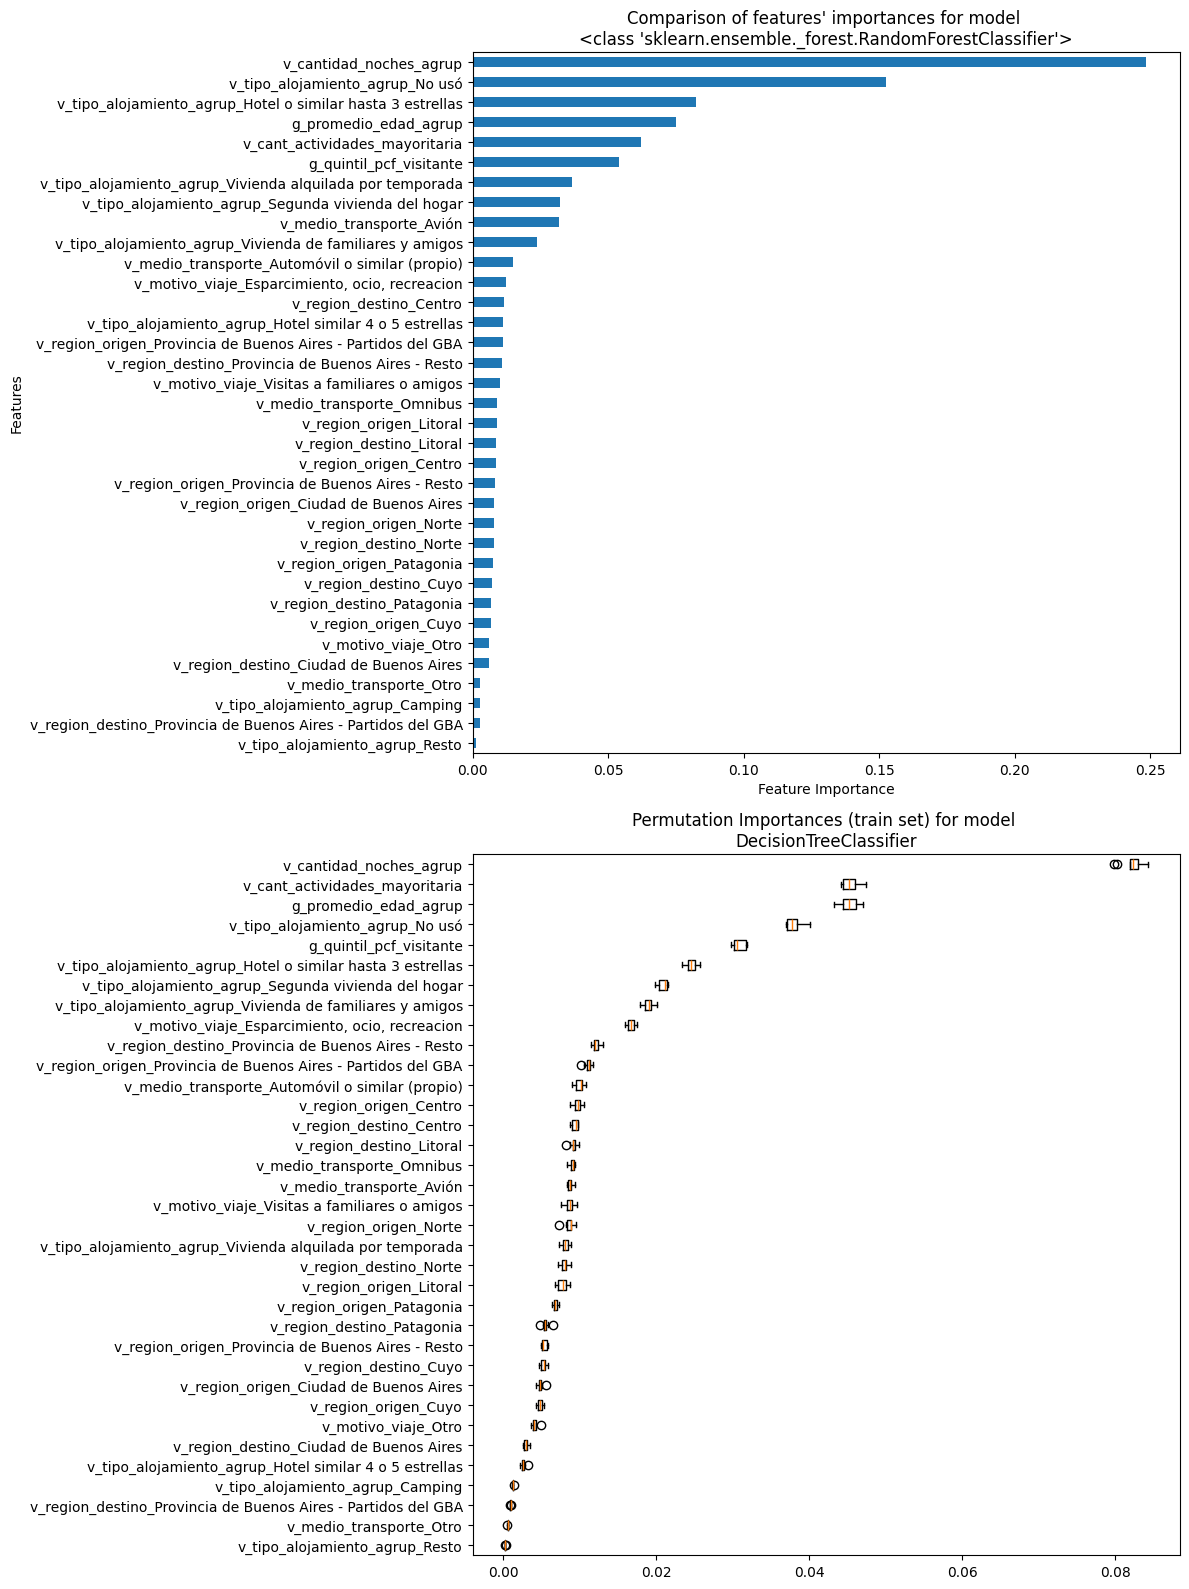

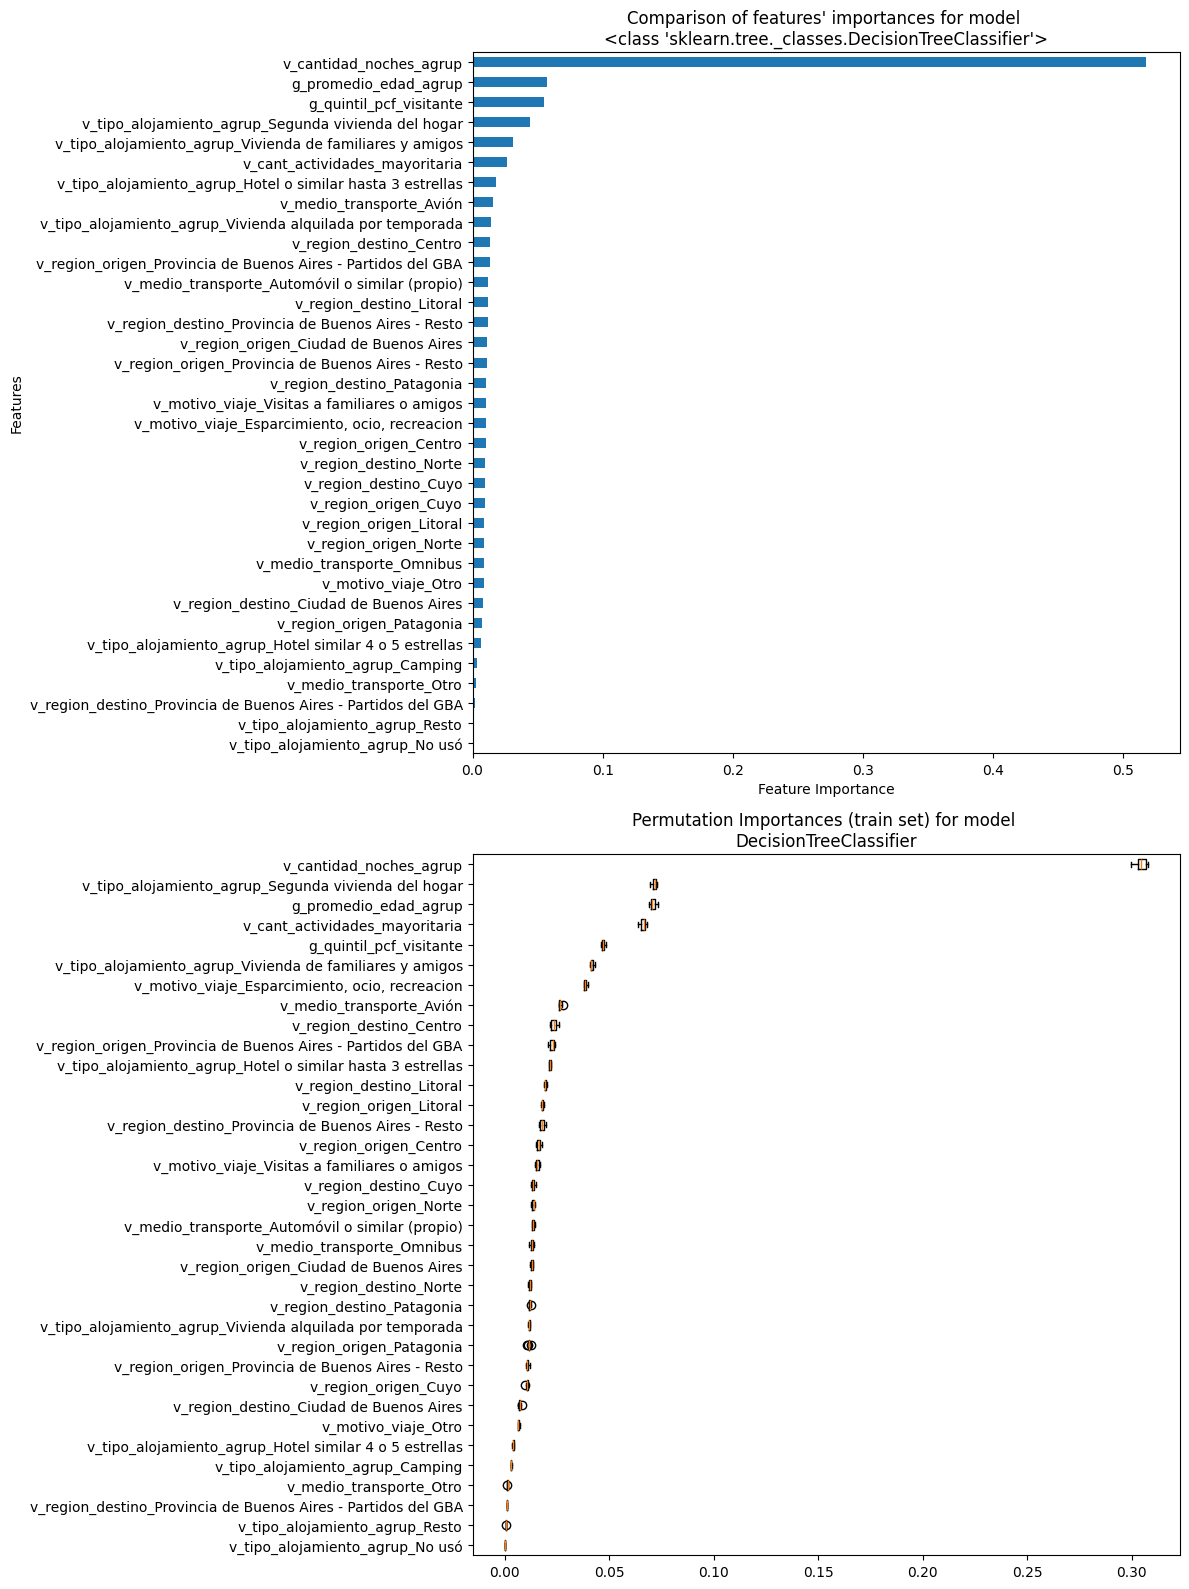

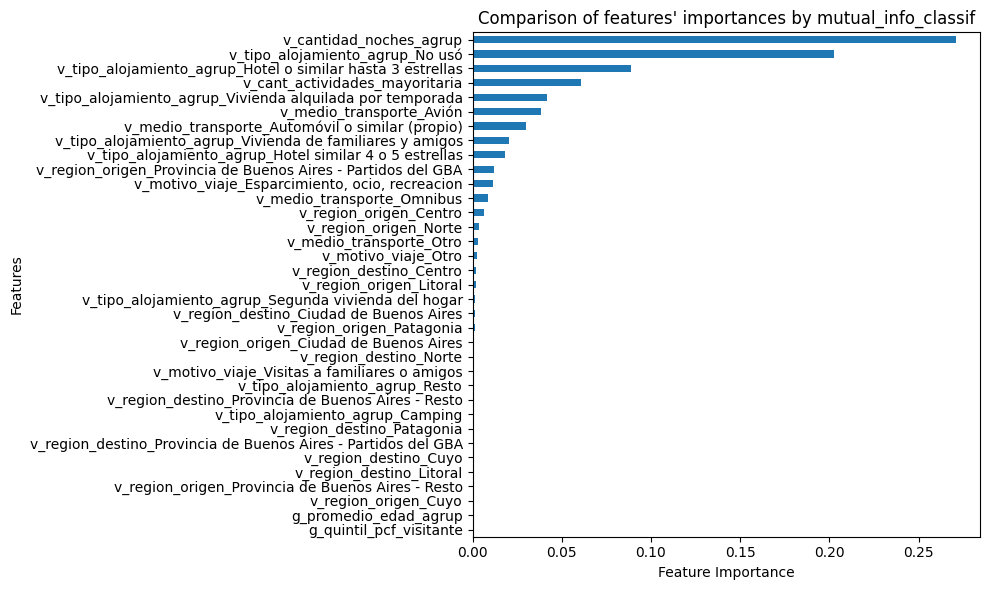

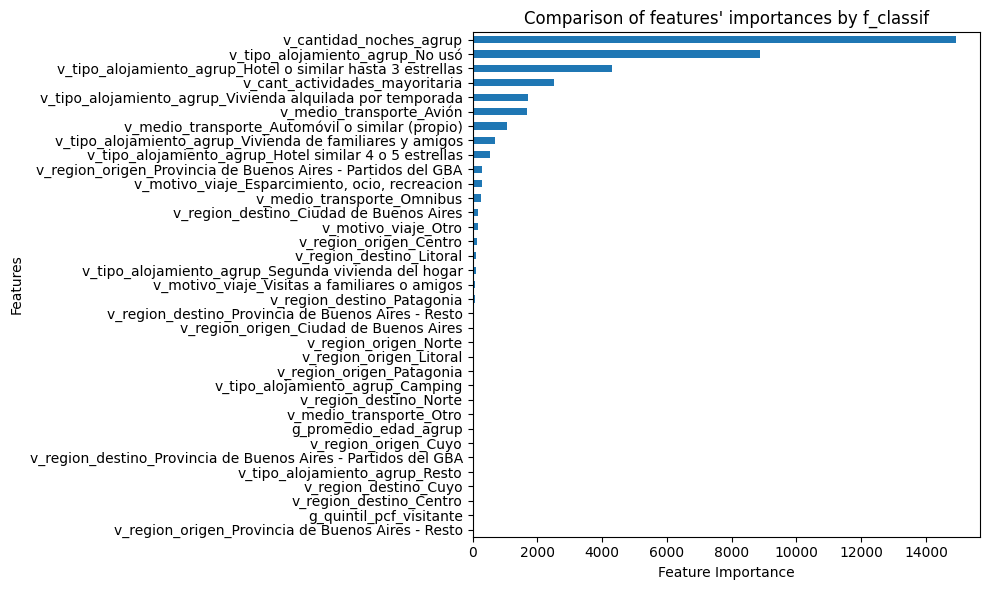

In [20]:
# Comparison of feature importance de Random Forest
# y Permutation importance de Random Forest
fig, ax = plt.subplots(2,1,figsize=(12,16))
clf = RandomForestClassifier(max_depth=None, random_state=0, n_jobs=6)
clf.fit(X_train_encoded, y_train)

feats = pd.Series(clf.feature_importances_, X_train_encoded.columns)
feats.sort_values(inplace=True, ascending=True)
feats.plot(kind='barh', ax=ax[0])
ax[0].set_xlabel('Feature Importance')
ax[0].set_ylabel('Features')
ax[0].set_title(f"Comparison of features' importances for model \n{clf.__class__}")

result = permutation_importance(clf, X_train_encoded, y_train, n_repeats=10, random_state=42, n_jobs=2)
sorted_idx = result.importances_mean.argsort()
ax[1].boxplot(result.importances[sorted_idx].T, vert=False, labels=X_train_encoded.columns[sorted_idx])
ax[1].set_title(f"Permutation Importances (train set) for model \nDecisionTreeClassifier")

fig.tight_layout()
plt.show()
plt.close()

# Comparison of feature importance de Decision Tree
# y Permutation importance de Decision Tree
fig, ax = plt.subplots(2,1,figsize=(12,16))
clf = DecisionTreeClassifier(criterion="entropy")
clf.fit(X_train_encoded, y_train)

feats = pd.Series(clf.feature_importances_, X_train_encoded.columns)
feats.sort_values(inplace=True, ascending=True)
feats.plot(kind='barh', ax=ax[0])
ax[0].set_xlabel('Feature Importance')
ax[0].set_ylabel('Features')
ax[0].set_title(f"Comparison of features' importances for model \n{clf.__class__}")

result = permutation_importance(clf, X_train_encoded, y_train, n_repeats=10, random_state=42, n_jobs=2)
sorted_idx = result.importances_mean.argsort()
ax[1].boxplot(result.importances[sorted_idx].T, vert=False, labels=X_train_encoded.columns[sorted_idx])
ax[1].set_title(f"Permutation Importances (train set) for model \nDecisionTreeClassifier")

fig.tight_layout()
plt.show()
plt.close()

# Comparison of feature importance by mutual_info_classif
fig, ax = plt.subplots(figsize=(10,6))

best_features = SelectKBest(score_func=mutual_info_classif, k='all')
fit = best_features.fit(X_train_encoded, y_train)
df_scores = pd.Series(fit.scores_, X_train_encoded.columns)
df_scores.sort_values(inplace=True, ascending=True)
df_scores.plot(kind='barh', ax=ax)
ax.set_xlabel('Feature Importance')
ax.set_ylabel('Features')
ax.set_title(f"Comparison of features' importances by mutual_info_classif")

fig.tight_layout()
plt.show()
plt.close()

# Comparison of feature importance by f_classif
fig, ax = plt.subplots(figsize=(10,6))

best_features = SelectKBest(score_func=f_classif, k='all')
fit = best_features.fit(X_train_encoded, y_train)
df_scores = pd.Series(fit.scores_, X_train_encoded.columns)
df_scores.sort_values(inplace=True, ascending=True)
df_scores.plot(kind='barh', ax=ax)
ax.set_xlabel('Feature Importance')
ax.set_ylabel('Features')
ax.set_title(f"Comparison of features' importances by f_classif")

fig.tight_layout()
plt.show()
plt.close()

# Classificación del dataset con variable target


In [21]:
X_train_encoded, y_train, X_test_encoded, y_test = separate_and_encode_dataset(dataset, target_column)
index_of_categorical_columns = [dataset.columns.get_loc(c) for c in list(dataset.select_dtypes(include=['category']).columns) ]
nominal_columns = list(dataset.select_dtypes(include=['object']).columns)
nominal_columns

['v_region_origen',
 'v_region_destino',
 'v_tipo_alojamiento_agrup',
 'v_medio_transporte',
 'v_motivo_viaje']

In [23]:
dataset.shape

(26937, 10)

In [24]:
#configuro binary_split como True para que me quede un arbol binario manejable (ya que sino al haber tantas ramas se complica la legibilidad)
river_model = tree.HoeffdingTreeClassifier( nominal_attributes=nominal_columns,binary_split=True)

acc = metrics.Accuracy()
cm = metrics.ConfusionMatrix()
#prec=metrics.Precision()
#rec=metrics.Recall()
report = metrics.ClassificationReport()
#model_metrics = [acc, cm]
model_metrics = [cm,report]

X_train, X_test = train_test_split( dataset.copy(), test_size=0.33, random_state=42)
#X_train, X_test = train_test_split( dataset.copy(), test_size=0.30, random_state=42)
y_train = X_train[target_column]
X_train = X_train.drop([target_column], axis=1)
y_test = X_test[target_column]
X_test = X_test.drop([target_column], axis=1)

for xi, yi in tqdm(stream.iter_pandas(X_train, y_train),total=X_train.shape[0]):
  river_model.learn_one(xi,yi)

for xi, yi in tqdm(stream.iter_pandas(X_test, y_test),total=X_test.shape[0]):
  yp=river_model.predict_one(xi)
  for m in model_metrics:
    m = m.update(yi, yp)


  0%|          | 0/18047 [00:00<?, ?it/s]

  0%|          | 0/8890 [00:00<?, ?it/s]

                   menos de 100 usd   más 100 usd  
menos de 100 usd              5,513           682  
     más 100 usd                394         2,301  
                   Precision   Recall   F1       Support  
                                                          
menos de 100 usd      93.33%   88.99%   91.11%      6195  
     más 100 usd      77.14%   85.38%   81.05%      2695  
                                                          
           Macro      85.23%   87.19%   86.08%            
           Micro      87.90%   87.90%   87.90%            
        Weighted      88.42%   87.90%   88.06%            

                     87.90% accuracy                      


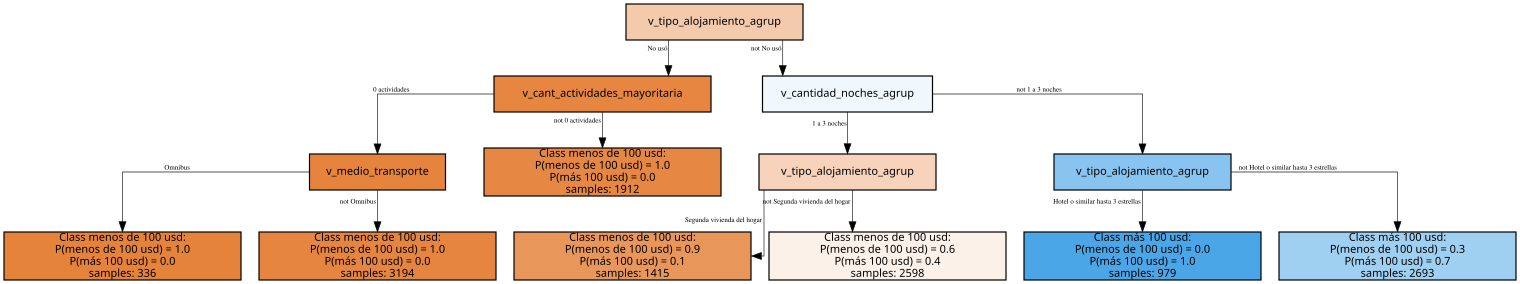

In [25]:
for m in model_metrics:
  print(m)
river_model.draw()

Se visualiza la relación entre las variables y la clase objetivo para interpretar patrones en los datos.

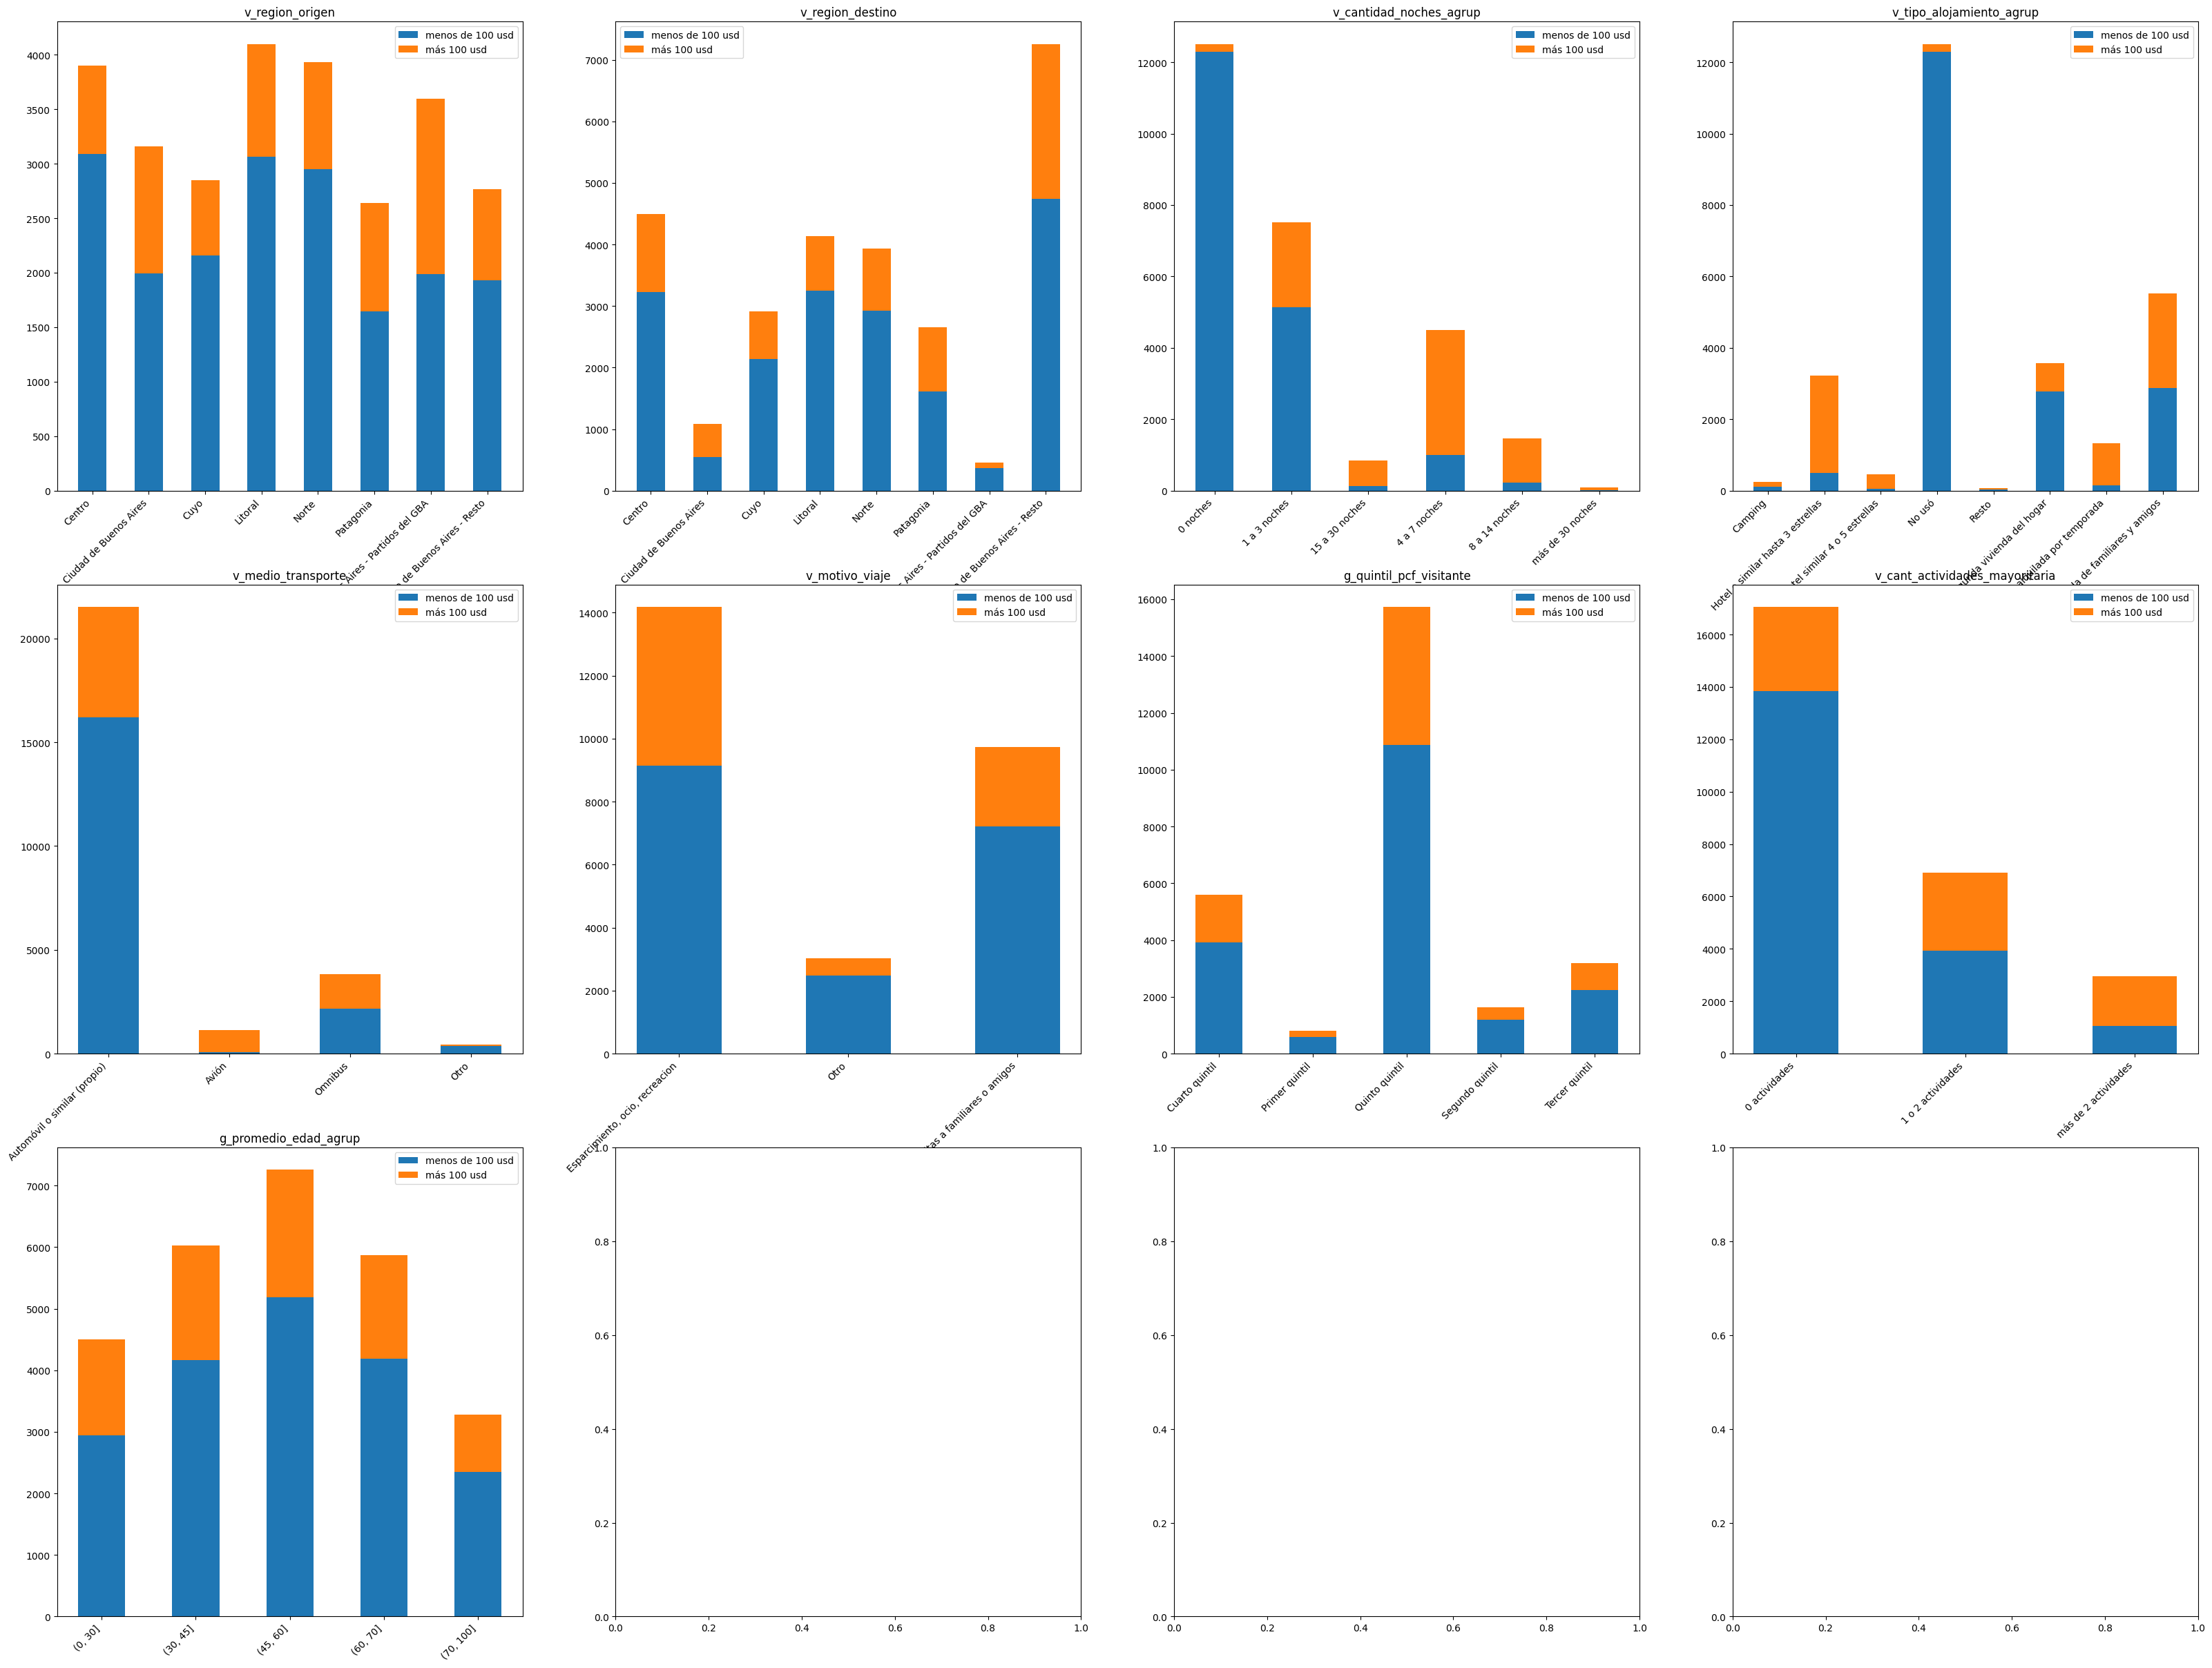

In [26]:
dataframe = dataset.copy()
total_columns = len(dataframe.columns)
columns = 4
individual_figsize = 10
rows = (total_columns // columns) + 1

fig, ax = plt.subplots(rows, columns, figsize=(columns*individual_figsize, rows * individual_figsize))
for idx, c in enumerate(dataframe.columns):
    if c != target_column:
      categories = dataframe[c].value_counts().index

      acc_counts = None
      for target_value in sorted(dataframe[target_column].unique()):
        counts = []
        for cat_value in sorted(categories):
          counts.append(dataframe.loc[(dataframe[target_column] ==target_value)& (dataframe[c]==cat_value)][c].count())

        ax[idx//columns,idx%columns].bar(sorted(categories), counts,  width=0.5, label=f"{target_value}", bottom = acc_counts)
        if acc_counts is None:
          acc_counts = np.array(counts)
        else:
          acc_counts += np.array(counts)
      ax[idx//columns,idx%columns].legend()
      ax[idx//columns,idx%columns].set_title(c)
      plt.setp(ax[idx//columns,idx%columns].get_xticklabels(), rotation=45, ha='right')
plt.show()
plt.close()

# Conclusiones

El objetivo final del trabajo es predecir el nivel de gasto turístico a partir de las características del viaje.

Para abordar este problema, se definió una estrategia de clasificación, discretizando el gasto en distintas categorías.

Previamente, se realizó un análisis para identificar los atributos más relevantes mediante distintos métodos de selección de variables, tales como *feature importance*, *permutation importance* y *SelectKBest*

Entre los atributos relevantes para explicar el gasto turístico se destacan:
- Origen y destino del viaje
- Tipo de alojamiento y cantidad de noches
- Medio de transporte
- Motivo del viaje
- Cantidad de actividades realizadas
- Variables socioeconómicas
- Edad promedio

A partir de este análisis, se seleccionaron las variables más relevantes para ser utilizadas en el modelo.

Para la etapa de modelado, se optó por utilizar un clasificador basado en árboles de decisión,
específicamente el algoritmo de **Hoeffding Tree**. Este modelo permite interpretar de manera clara los criterios utilizados en la toma de decisiones, lo cual resulta valioso en un contexto analítico.

Los resultados obtenidos muestran que es posible construir modelos predictivos del gasto turístico a partir de datos provenientes de encuestas.

El análisis permitió:
- Identificar variables clave en la determinación del gasto
- Utilizar dichas variables en un modelo de clasificación interpretable
- Explorar un enfoque de modelado supervisado sobre datos reales

Este tipo de análisis puede ser útil para la toma de decisiones en el ámbito del turismo, permitiendo segmentar perfiles de viajeros y anticipar comportamientos de consumo.

## Limitaciones del trabajo

- Los datos provienen de encuestas, por lo que pueden contener sesgos, valores faltantes o imprecisiones.
- La variable objetivo fue discretizada, lo que simplifica el problema pero implica pérdida de información respecto al gasto real.
- Los resultados obtenidos corresponden al dataset analizado y no necesariamente son generalizables a otros contextos o poblaciones.